<a href="https://colab.research.google.com/github/Jayalakshmi-27-05/Syntecxhub_projects/blob/main/Syntecxhub_Maze_Solver_using_A_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import math
import random
from matplotlib.colors import ListedColormap
import collections # Added for BFS
import pandas as pd # Added for DataFrames
import seaborn as sns # Added for plotting
import time # Added for timing algorithms

In [ ]:
def generate_maze(size=10, obstacle_prob=0.2):
    maze = np.zeros((size, size))

    for i in range(size):
        for j in range(size):
            if random.random() < obstacle_prob:
                maze[i][j] = 1

    return maze

In [ ]:
def heuristic(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

In [ ]:
def astar(maze, start, goal):
    rows, cols = maze.shape

    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    g_score = {start: 0}

    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for d in directions:
            neighbor = (current[0]+d[0], current[1]+d[1])

            if (0 <= neighbor[0] < rows and
                0 <= neighbor[1] < cols and
                maze[neighbor] == 0):

                # Use calculate_step_distance for actual step cost in unweighted maze
                step_cost = calculate_step_distance(current, neighbor)
                temp_g = g_score[current] + step_cost

                if neighbor not in g_score or temp_g < g_score[neighbor]:
                    g_score[neighbor] = temp_g
                    # Use heuristic_to_goal for the heuristic component
                    f_score = temp_g + heuristic_to_goal(neighbor, goal)
                    heapq.heappush(open_list, (f_score, neighbor))
                    came_from[neighbor] = current

    return None

In [ ]:
print("Generating solvable maze...")

while True:
    maze = generate_maze(10, 0.2)

    start = (0, 0)
    goal = (maze.shape[0]-1, maze.shape[1]-1)

    # Ensure start & goal are free
    maze[start] = 0
    maze[goal] = 0

    path = astar(maze, start, goal)

    if path:
        break

Generating solvable maze...


In [ ]:
print("Shortest Path Found!")
print("Path:", path)
print("Path Length:", len(path))

Shortest Path Found!
Path: [(0, 0), (1, 0), (2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6), (8, 7), (9, 8), (9, 9)]
Path Length: 11


In [ ]:
def visualize(maze, path, start, goal, title="Maze Solver - Final Path", path_color=2, output_filename=None):
    vis = np.copy(maze)

    if path:
        for p in path:
            vis[p] = path_color # Use provided path_color

    vis[start] = 3
    vis[goal] = 4

    # Color mapping: 0=empty, 1=wall, path_color=path, 3=start, 4=goal
    # We'll use 2 for A* path (cyan), 5 for Dijkstra's path (orange), and 6 for BFS (red)
    cmap = ListedColormap(['purple', 'black', 'cyan', 'green', 'yellow', 'orange', 'red'])

    plt.figure(figsize=(6,6))
    plt.imshow(vis, cmap=cmap)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    if output_filename:
        plt.savefig(output_filename)
    plt.show()

### Introducing Weighted Terrain Costs

In [ ]:
def calculate_step_distance(node1, node2):
    """Calculates Euclidean distance for a single step (cardinal=1, diagonal=sqrt(2))."""
    dr = abs(node1[0] - node2[0])
    dc = abs(node1[1] - node2[1])
    if dr == 1 and dc == 0: return 1.0 # Cardinal
    if dr == 0 and dc == 1: return 1.0 # Cardinal
    if dr == 1 and dc == 1: return math.sqrt(2) # Diagonal
    return 0.0 # Should not happen for adjacent cells, but for safety

def heuristic_to_goal(a, b):
    """Calculates Euclidean distance as a heuristic to the goal."""
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)


Now, let's create a function to generate a maze with varying terrain costs. We'll assign a 'normal' cost to some path cells and a higher 'mud' cost to others. Walls will have an infinite cost.

In [ ]:
def create_weighted_maze(binary_maze, normal_cost=1.0, mud_cost=5.0, mud_prob=0.2):
    """Transforms a binary maze (0=path, 1=wall) into a weighted cost map."""
    weighted_maze = np.full(binary_maze.shape, float('inf')) # Walls are infinite cost

    rows, cols = binary_maze.shape
    for r in range(rows):
        for c in range(cols):
            if binary_maze[r, c] == 0:  # If it's a path cell
                if random.random() < mud_prob:
                    weighted_maze[r, c] = mud_cost
                else:
                    weighted_maze[r, c] = normal_cost
    return weighted_maze


Next, we'll modify the `astar` and `dijkstra` algorithms to use this weighted cost map. BFS will remain an unweighted shortest path (by number of steps) algorithm for comparison.

In [ ]:
# Modified A* algorithm for weighted mazes
def astar_weighted(weighted_maze, start, goal):
    rows, cols = weighted_maze.shape

    open_list = []
    heapq.heappush(open_list, (0, start)) # (f_score, node)

    came_from = {}
    g_score = {start: 0} # Actual cost from start to current node

    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    while open_list:
        current_f_score, current = heapq.heappop(open_list)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1] # Return reversed path

        for d in directions:
            neighbor = (current[0]+d[0], current[1]+d[1])

            # Check if neighbor is within bounds and not an obstacle (infinite cost)
            if (0 <= neighbor[0] < rows and
                0 <= neighbor[1] < cols and
                weighted_maze[neighbor] != float('inf')):

                step_dist = calculate_step_distance(current, neighbor)
                # Cost to reach neighbor = current g_score + cost of entering neighbor * distance of step
                temp_g = g_score[current] + weighted_maze[neighbor] * step_dist

                if neighbor not in g_score or temp_g < g_score[neighbor]:
                    g_score[neighbor] = temp_g
                    f_score = temp_g + heuristic_to_goal(neighbor, goal)
                    heapq.heappush(open_list, (f_score, neighbor))
                    came_from[neighbor] = current

    return None # No path found


In [ ]:
# Modified Dijkstra's algorithm for weighted mazes
def dijkstra_weighted(weighted_maze, start, goal):
    rows, cols = weighted_maze.shape
    pq = [(0, start)] # Priority queue: (cost, node)
    distances = {start: 0}
    previous_nodes = {}

    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        if current_node == goal:
            path = []
            while current_node in previous_nodes:
                path.append(current_node)
                current_node = previous_nodes[current_node]
            path.append(start)
            return path[::-1]

        if current_distance > distances[current_node]:
            continue

        for d in directions:
            neighbor = (current_node[0] + d[0], current_node[1] + d[1])

            if (0 <= neighbor[0] < rows and
                0 <= neighbor[1] < cols and
                weighted_maze[neighbor] != float('inf')):

                step_dist = calculate_step_distance(current_node, neighbor)
                # Cost to move to neighbor = cost of entering neighbor * distance of step
                cost_to_neighbor = weighted_maze[neighbor] * step_dist
                distance = current_distance + cost_to_neighbor

                if distance < distances.get(neighbor, float('inf')):
                    distances[neighbor] = distance
                    previous_nodes[neighbor] = current_node
                    heapq.heappush(pq, (distance, neighbor))

    return None # No path found


Finally, we need to update the `visualize` function to properly display the weighted maze with different terrain colors and the new path colors.

In [ ]:
# Modified visualize function for weighted mazes and new color mapping
def visualize_weighted(base_maze, path, start, goal, title="Maze Solver - Weighted Path", path_color_code=3):
    # Map base_maze values (inf, 1.0, 5.0) to integers for ListedColormap
    vis_map = np.zeros(base_maze.shape, dtype=int)
    vis_map[base_maze == float('inf')] = 0  # Wall
    vis_map[base_maze == 1.0] = 1         # Normal Path
    vis_map[base_maze == 5.0] = 2         # Mud Path

    if path:
        for p in path:
            vis_map[p] = path_color_code # Path code

    vis_map[start] = 6 # Start
    vis_map[goal] = 7  # Goal

    # Define colors for the new integer mapping
    # 0=Wall, 1=Normal Path, 2=Mud Path, 3=A* Path, 4=Dijkstra Path, 5=BFS Path, 6=Start, 7=Goal
    colors = ['black', 'lightgrey', 'saddlebrown', 'cyan', 'orange', 'red', 'green', 'yellow']
    cmap = ListedColormap(colors[:len(np.unique(vis_map))]) # Adjust cmap to actual number of unique values

    plt.figure(figsize=(8,8))
    plt.imshow(vis_map, cmap=cmap, interpolation='nearest')
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()


### Demonstration with Weighted Maze

Generated a weighted maze with normal paths (cost 1.0) and mud paths (cost 5.0).


,Algorithm,Total Cost / Steps,Number of Steps
0,A* (Weighted Cost),193.74,91
1,Dijkstra (Weighted Cost),193.74,91
2,BFS (Steps),81.00,81


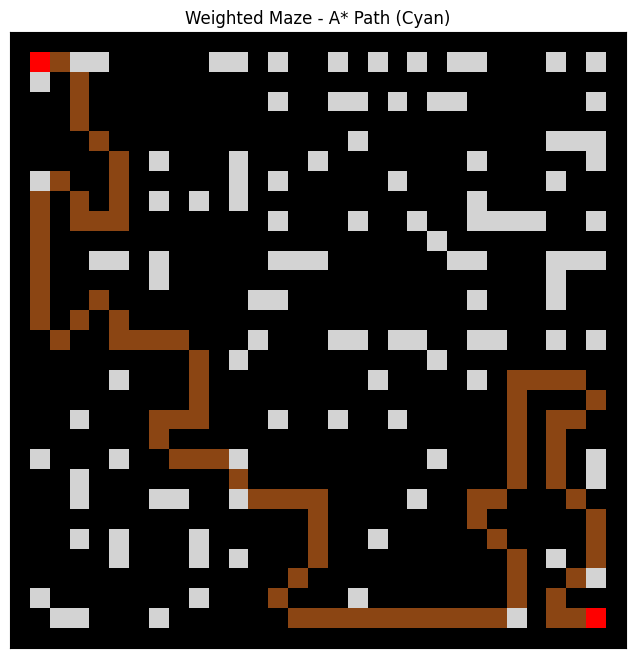

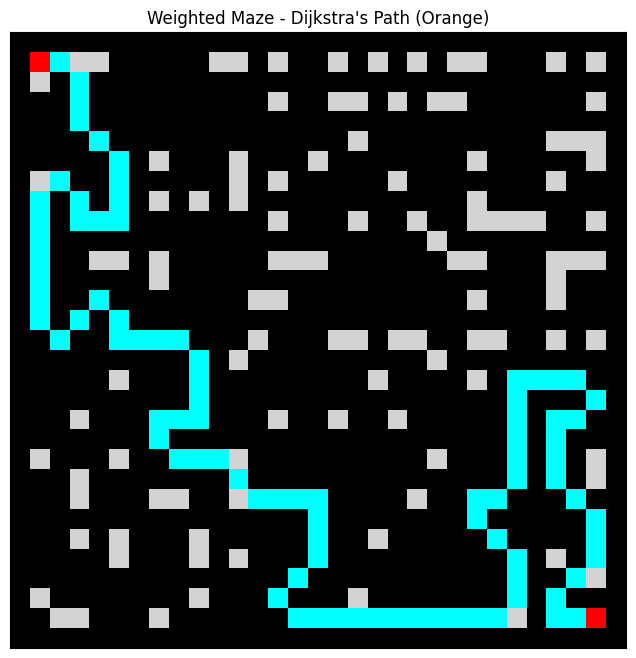

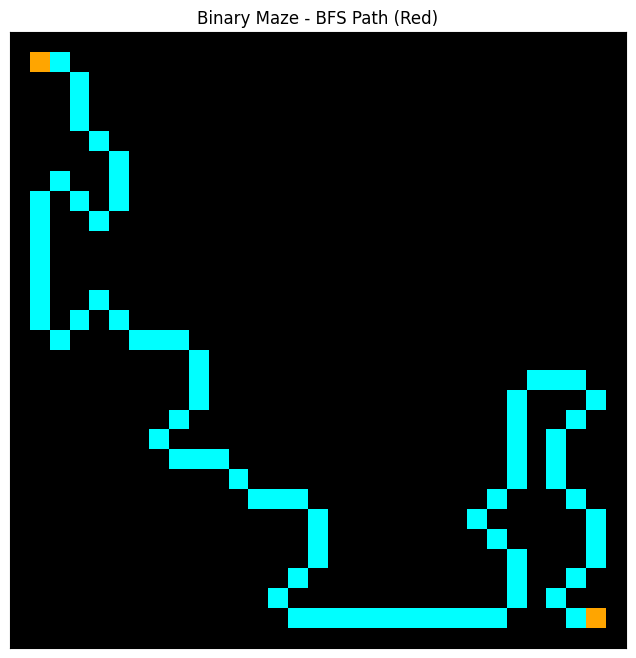

In [ ]:
# Generate a new binary maze using the recursive backtracker
maze_size_conceptual_weighted = 15 # A slightly larger maze for better terrain visualization
binary_maze_weighted = generate_maze_recursive_backtracker(size=maze_size_conceptual_weighted)

# Create a weighted maze from the binary maze
weighted_maze_costs = create_weighted_maze(binary_maze_weighted, normal_cost=1.0, mud_cost=5.0, mud_prob=0.3)

# Define start and goal (in conceptual maze coordinates)
start_weighted = (1, 1)
goal_weighted = (weighted_maze_costs.shape[0] - 2, weighted_maze_costs.shape[1] - 2)

# Ensure start and goal are always normal path cells
weighted_maze_costs[start_weighted] = 1.0
weighted_maze_costs[goal_weighted] = 1.0

print("Generated a weighted maze with normal paths (cost 1.0) and mud paths (cost 5.0).")

# Find paths using the modified algorithms
path_astar_weighted = astar_weighted(weighted_maze_costs, start_weighted, goal_weighted)
path_dijkstra_weighted = dijkstra_weighted(weighted_maze_costs, start_weighted, goal_weighted)
path_bfs_unweighted = bfs(binary_maze_weighted, start_weighted, goal_weighted) # BFS on binary maze for steps

# Calculate actual total costs for A* and Dijkstra
def calculate_path_cost(path, weighted_maze):
    if not path or len(path) < 2:
        return 0
    total_cost = 0
    for i in range(1, len(path)):
        current_node = path[i-1]
        next_node = path[i]
        step_dist = calculate_step_distance(current_node, next_node)
        total_cost += weighted_maze[next_node] * step_dist
    return total_cost

# Display path costs and lengths
weighted_path_costs = {
    'Algorithm': ['A* (Weighted Cost)', 'Dijkstra (Weighted Cost)', 'BFS (Steps)'],
    'Total Cost / Steps': [
        round(calculate_path_cost(path_astar_weighted, weighted_maze_costs), 2) if path_astar_weighted else 'No Path',
        round(calculate_path_cost(path_dijkstra_weighted, weighted_maze_costs), 2) if path_dijkstra_weighted else 'No Path',
        len(path_bfs_unweighted) if path_bfs_unweighted else 'No Path'
    ],
    'Number of Steps': [
        len(path_astar_weighted) if path_astar_weighted else 'No Path',
        len(path_dijkstra_weighted) if path_dijkstra_weighted else 'No Path',
        len(path_bfs_unweighted) if path_bfs_unweighted else 'No Path'
    ]
}
df_weighted_comparison = pd.DataFrame(weighted_path_costs)
display(df_weighted_comparison)

# Visualize paths on the weighted maze
visualize_weighted(weighted_maze_costs, path_astar_weighted, start_weighted, goal_weighted, title="Weighted Maze - A* Path (Cyan)", path_color_code=3)
visualize_weighted(weighted_maze_costs, path_dijkstra_weighted, start_weighted, goal_weighted, title="Weighted Maze - Dijkstra's Path (Orange)", path_color_code=4)
visualize_weighted(binary_maze_weighted, path_bfs_unweighted, start_weighted, goal_weighted, title="Binary Maze - BFS Path (Red)", path_color_code=5)


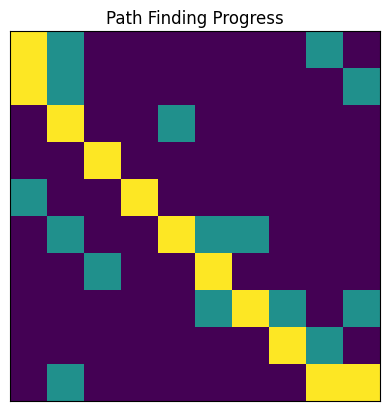

In [ ]:
from IPython.display import clear_output
import time

def animate_path(maze, path):
    vis = np.copy(maze)

    for step in path:
        vis[step] = 2
        clear_output(wait=True)

        plt.imshow(vis, cmap='viridis')
        plt.title("Path Finding Progress")
        plt.xticks([])
        plt.yticks([])
        plt.show()

        time.sleep(0.2)

animate_path(maze, path)

In [ ]:
def generate_maze_recursive_backtracker(size=10):
    # Initialize maze with all walls (1) and unvisited cells (0)
    maze = np.ones((size * 2 + 1, size * 2 + 1))

    # Function to check if a cell is within bounds
    def is_valid(r, c):
        return 0 <= r < size and 0 <= c < size

    # Function to get unvisited neighbors
    def get_unvisited_neighbors(current_r, current_c, visited):
        neighbors = []
        # Define potential directions: Up, Down, Left, Right
        # Each move is 2 steps to ensure we land on a cell, not a wall
        for dr, dc, wall_dr, wall_dc in [
            (-1, 0, -1, 0), (1, 0, 1, 0), (0, -1, 0, -1), (0, 1, 0, 1)
        ]:
            next_r, next_c = current_r + dr, current_c + dc
            if is_valid(next_r, next_c) and not visited[next_r][next_c]:
                neighbors.append(((next_r, next_c), (current_r + wall_dr, current_c + wall_dc)))
        return neighbors

    # Convert conceptual maze coordinates to actual numpy array indices
    # (0,0) in conceptual maze -> (1,1) in numpy array
    def map_to_numpy_coords(r, c):
        return 2 * r + 1, 2 * c + 1

    # Stack for backtracking
    stack = []
    # Keep track of visited cells in the conceptual maze (size x size)
    visited = np.zeros((size, size), dtype=bool)

    # Start at a random cell
    start_r, start_c = random.randint(0, size - 1), random.randint(0, size - 1)

    # Carve out the starting cell
    np_start_r, np_start_c = map_to_numpy_coords(start_r, start_c)
    maze[np_start_r][np_start_c] = 0
    visited[start_r][start_c] = True
    stack.append((start_r, start_c))

    while stack:
        current_r, current_c = stack[-1]
        unvisited_neighbors = get_unvisited_neighbors(current_r, current_c, visited)

        if unvisited_neighbors:
            # Choose a random unvisited neighbor
            (next_r, next_c), (wall_r, wall_c) = random.choice(unvisited_neighbors)

            # Carve path (remove wall and make next cell a path)
            np_current_r, np_current_c = map_to_numpy_coords(current_r, current_c)
            np_next_r, np_next_c = map_to_numpy_coords(next_r, next_c)

            # Calculate wall position in numpy maze
            np_wall_r = np_current_r + (np_next_r - np_current_r) // 2
            np_wall_c = np_current_c + (np_next_c - np_current_c) // 2

            maze[np_wall_r][np_wall_c] = 0 # Remove the wall
            maze[np_next_r][np_next_c] = 0 # Carve the next cell

            visited[next_r][next_c] = True
            stack.append((next_r, next_c))
        else:
            # Backtrack if no unvisited neighbors
            stack.pop()

    return maze

Generated a maze using Recursive Backtracker.
Shortest Path Found! Path Length: 38


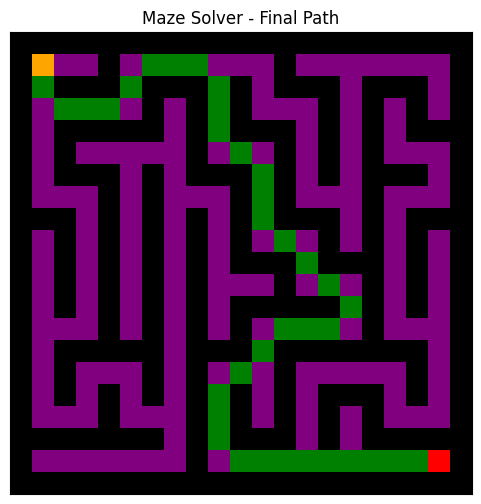

In [ ]:
# Generate a new maze using the recursive backtracker
maze_size_conceptual = 10 # This refers to the grid of cells, not the numpy array size
new_maze = generate_maze_recursive_backtracker(size=maze_size_conceptual)

# Define start and goal for the new maze
# These need to be on the 'path' cells of the numpy array
# (1,1) for the top-left cell, (2*size-1, 2*size-1) for the bottom-right
start_new = (1, 1)
goal_new = (new_maze.shape[0] - 2, new_maze.shape[1] - 2)

print("Generated a maze using Recursive Backtracker.")

# Ensure start and goal are clear in case of very specific maze generation edge cases
new_maze[start_new] = 0
new_maze[goal_new] = 0

# Find the path using A*
path_new = astar(new_maze, start_new, goal_new)

if path_new:
    print(f"Shortest Path Found! Path Length: {len(path_new)}")
    visualize(new_maze, path_new, start_new, goal_new)
else:
    print("No path found in the new maze.")

In [ ]:
def dijkstra(maze, start, goal):
    rows, cols = maze.shape
    pq = [(0, start)] # Priority queue: (cost, node)
    distances = {start: 0}
    previous_nodes = {}

    # Directions for 8-directional movement (same as A*)
    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        if current_node == goal:
            path = []
            while current_node in previous_nodes:
                path.append(current_node)
                current_node = previous_nodes[current_node]
            path.append(start)
            return path[::-1]

        if current_distance > distances[current_node]:
            continue

        for d in directions:
            neighbor = (current_node[0] + d[0], current_node[1] + d[1])

            if (0 <= neighbor[0] < rows and
                0 <= neighbor[1] < cols and
                maze[neighbor] == 0): # Ensure neighbor is within bounds and not an obstacle

                # Cost to move to neighbor (using calculate_step_distance for uniform cost in binary maze)
                move_cost = calculate_step_distance(current_node, neighbor)
                distance = current_distance + move_cost

                if distance < distances.get(neighbor, float('inf')):
                    distances[neighbor] = distance
                    previous_nodes[neighbor] = current_node
                    heapq.heappush(pq, (distance, neighbor))

    return None

## Consolidated Demonstrations and Comparisons

### 1. Unweighted Maze Pathfinding (A*, Dijkstra, BFS)

Generated a maze using Recursive Backtracker.

Path Length Comparison (Unweighted Maze):


,Algorithm,Path Length
0,A*,36
1,Dijkstra,36
2,BFS,36


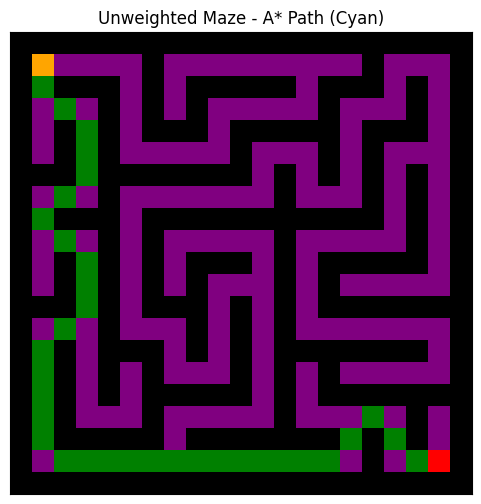

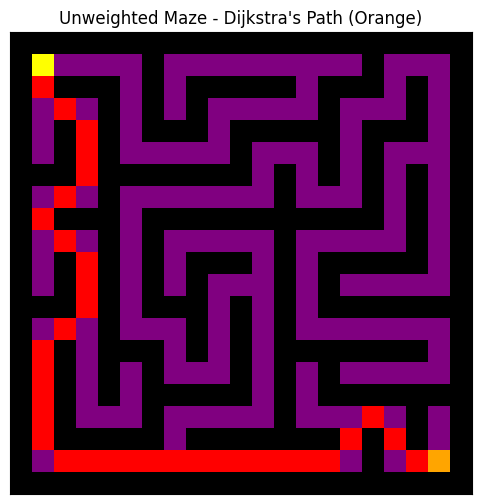

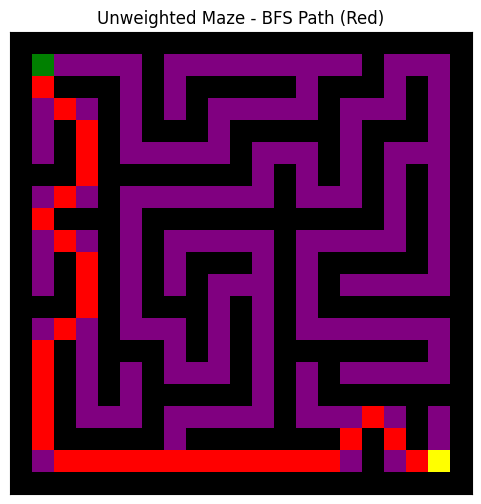

In [ ]:
# Generate a new maze using the recursive backtracker
maze_size_conceptual = 10 # This refers to the grid of cells, not the numpy array size
new_maze = generate_maze_recursive_backtracker(size=maze_size_conceptual)

# Define start and goal for the new maze
# These need to be on the 'path' cells of the numpy array
# (1,1) for the top-left cell, (2*size-1, 2*size-1) for the bottom-right
start_new = (1, 1)
goal_new = (new_maze.shape[0] - 2, new_maze.shape[1] - 2)

# Ensure start and goal are clear in case of very specific maze generation edge cases
new_maze[start_new] = 0
new_maze[goal_new] = 0

print("Generated a maze using Recursive Backtracker.")

# Find paths using all three algorithms
path_astar = astar(new_maze, start_new, goal_new)
path_dijkstra = dijkstra(new_maze, start_new, goal_new)
path_bfs = bfs(new_maze, start_new, goal_new)

# Display path lengths comparison
path_lengths = {
    'Algorithm': ['A*', 'Dijkstra', 'BFS'],
    'Path Length': [
        len(path_astar) if path_astar else 'No Path',
        len(path_dijkstra) if path_dijkstra else 'No Path',
        len(path_bfs) if path_bfs else 'No Path'
    ]
}
df_comparison = pd.DataFrame(path_lengths)
print("\nPath Length Comparison (Unweighted Maze):")
display(df_comparison)

# Visualize paths
if path_astar: visualize(new_maze, path_astar, start_new, goal_new, title="Unweighted Maze - A* Path (Cyan)", path_color=2)
if path_dijkstra: visualize(new_maze, path_dijkstra, start_new, goal_new, title="Unweighted Maze - Dijkstra's Path (Orange)", path_color=5)
if path_bfs: visualize(new_maze, path_bfs, start_new, goal_new, title="Unweighted Maze - BFS Path (Red)", path_color=6)
else: print("No path found for one or more algorithms in the unweighted maze.")

### 2. Weighted Maze Pathfinding (A*, Dijkstra, BFS)

Generated a weighted maze with normal paths (cost 1.0) and mud paths (cost 5.0).

Path Cost and Length Comparison (Weighted Maze):


,Algorithm,Total Cost / Steps,Number of Steps
0,A* (Weighted Cost),137.84,70
1,Dijkstra (Weighted Cost),137.84,70
2,BFS (Steps),65.00,65


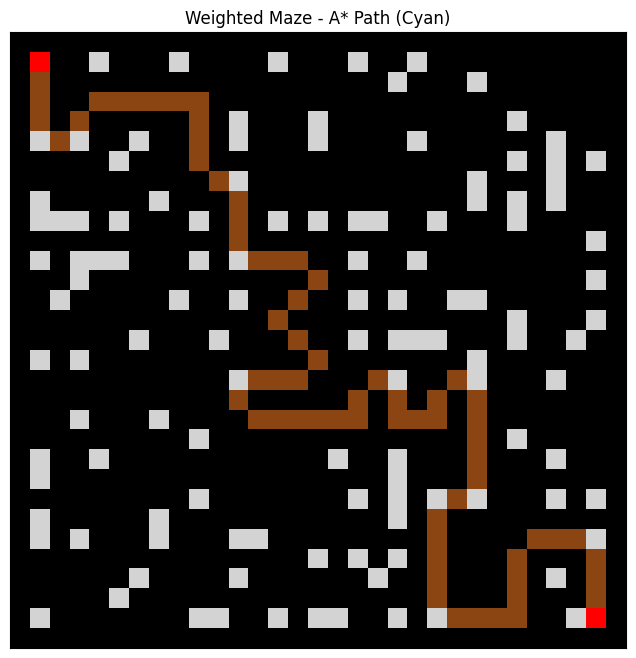

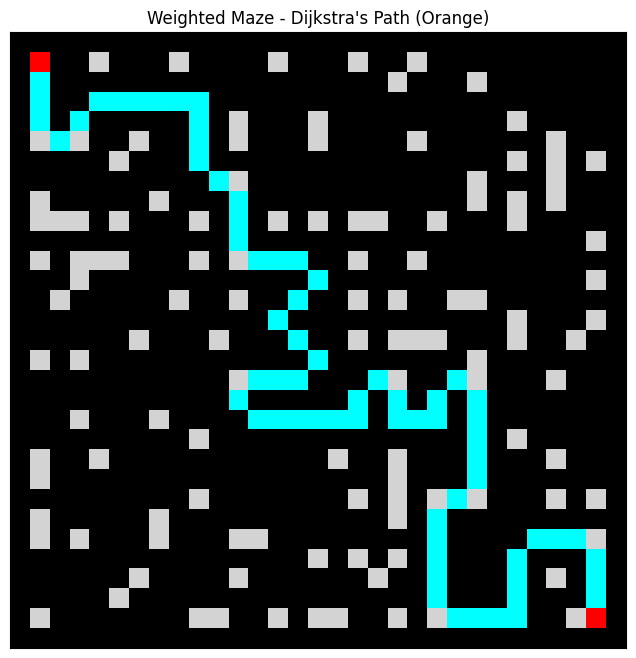

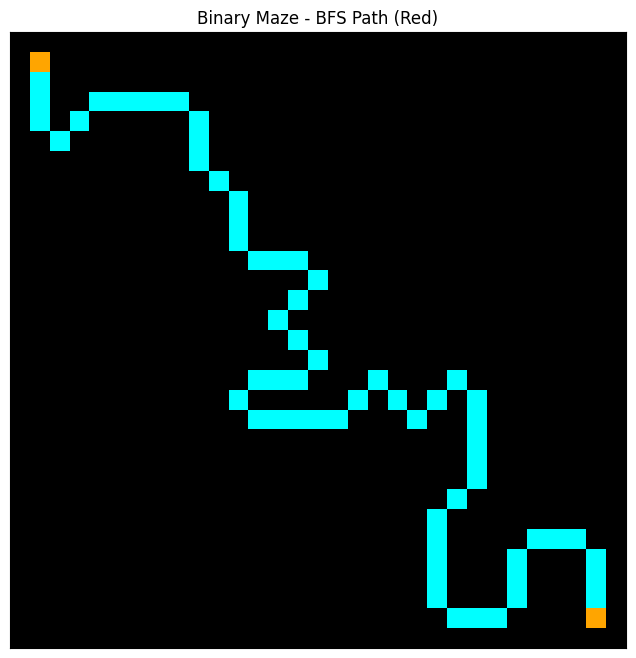

In [ ]:
# Generate a new binary maze using the recursive backtracker
maze_size_conceptual_weighted = 15 # A slightly larger maze for better terrain visualization
binary_maze_weighted = generate_maze_recursive_backtracker(size=maze_size_conceptual_weighted)

# Create a weighted maze from the binary maze
weighted_maze_costs = create_weighted_maze(binary_maze_weighted, normal_cost=1.0, mud_cost=5.0, mud_prob=0.3)

# Define start and goal (in conceptual maze coordinates)
start_weighted = (1, 1)
goal_weighted = (weighted_maze_costs.shape[0] - 2, weighted_maze_costs.shape[1] - 2)

# Ensure start and goal are always normal path cells
weighted_maze_costs[start_weighted] = 1.0
weighted_maze_costs[goal_weighted] = 1.0

print("Generated a weighted maze with normal paths (cost 1.0) and mud paths (cost 5.0).")

# Find paths using the modified algorithms
path_astar_weighted = astar_weighted(weighted_maze_costs, start_weighted, goal_weighted)
path_dijkstra_weighted = dijkstra_weighted(weighted_maze_costs, start_weighted, goal_weighted)
# BFS still runs on the binary maze to compare step-optimal vs cost-optimal
path_bfs_unweighted = bfs(binary_maze_weighted, start_weighted, goal_weighted)

# Calculate actual total costs for A* and Dijkstra
def calculate_path_cost(path, weighted_maze):
    if not path or len(path) < 2:
        return 0
    total_cost = 0
    for i in range(1, len(path)):
        current_node = path[i-1]
        next_node = path[i]
        step_dist = calculate_step_distance(current_node, next_node)
        # For weighted algorithms, cost is terrain cost of the next node * step_distance
        total_cost += weighted_maze[next_node] * step_dist
    return total_cost

# Display path costs and lengths
weighted_path_costs = {
    'Algorithm': ['A* (Weighted Cost)', 'Dijkstra (Weighted Cost)', 'BFS (Steps)'],
    'Total Cost / Steps': [
        round(calculate_path_cost(path_astar_weighted, weighted_maze_costs), 2) if path_astar_weighted else 'No Path',
        round(calculate_path_cost(path_dijkstra_weighted, weighted_maze_costs), 2) if path_dijkstra_weighted else 'No Path',
        len(path_bfs_unweighted) if path_bfs_unweighted else 'No Path' # BFS cost is just steps here
    ],
    'Number of Steps': [
        len(path_astar_weighted) if path_astar_weighted else 'No Path',
        len(path_dijkstra_weighted) if path_dijkstra_weighted else 'No Path',
        len(path_bfs_unweighted) if path_bfs_unweighted else 'No Path'
    ]
}
df_weighted_comparison = pd.DataFrame(weighted_path_costs)
print("\nPath Cost and Length Comparison (Weighted Maze):")
display(df_weighted_comparison)

# Visualize paths on the weighted maze
if path_astar_weighted: visualize_weighted(weighted_maze_costs, path_astar_weighted, start_weighted, goal_weighted, title="Weighted Maze - A* Path (Cyan)", path_color_code=3)
if path_dijkstra_weighted: visualize_weighted(weighted_maze_costs, path_dijkstra_weighted, start_weighted, goal_weighted, title="Weighted Maze - Dijkstra's Path (Orange)", path_color_code=4)
# BFS visualization on the binary maze, not the weighted cost map
if path_bfs_unweighted: visualize_weighted(binary_maze_weighted, path_bfs_unweighted, start_weighted, goal_weighted, title="Binary Maze - BFS Path (Red)", path_color_code=5)
else: print("No path found for one or more algorithms in the weighted maze.")

### 3. Algorithm Performance Benchmarking on Larger Maze

Generated a larger maze (20x20 conceptual size).

Computational times for larger maze: {'A*': 0.0013299000002007233, 'Dijkstra': 0.0012691600004473003, 'BFS': 0.0009945699994204915}

Path Length Comparison (Larger Maze):


,Algorithm,Path Length
0,A*,174
1,Dijkstra,174
2,BFS,174


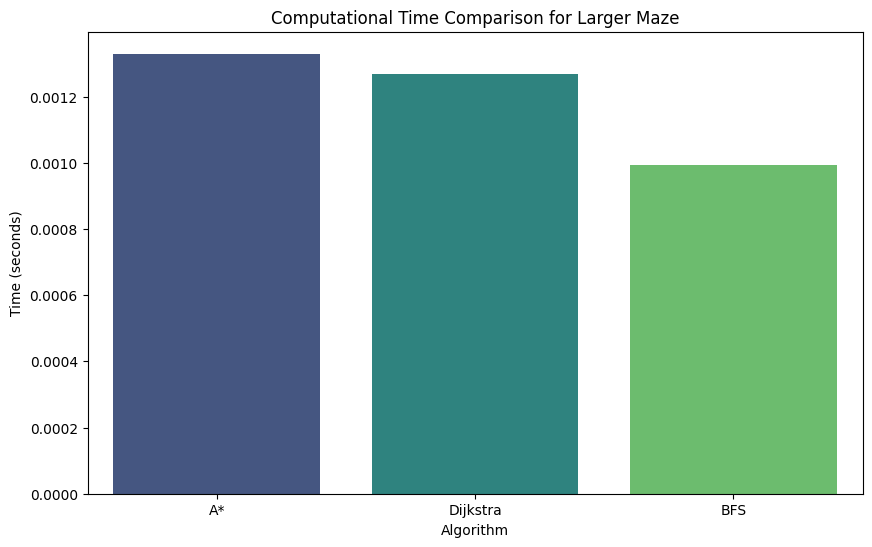

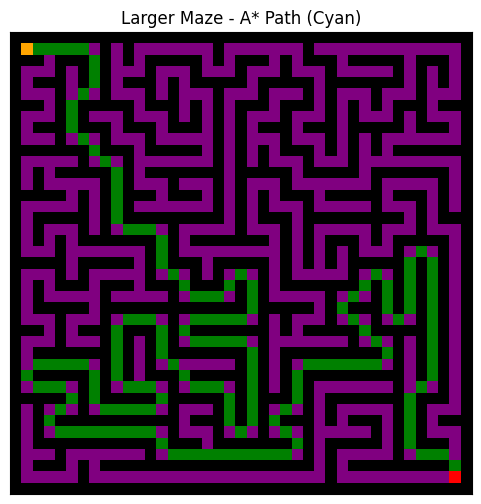

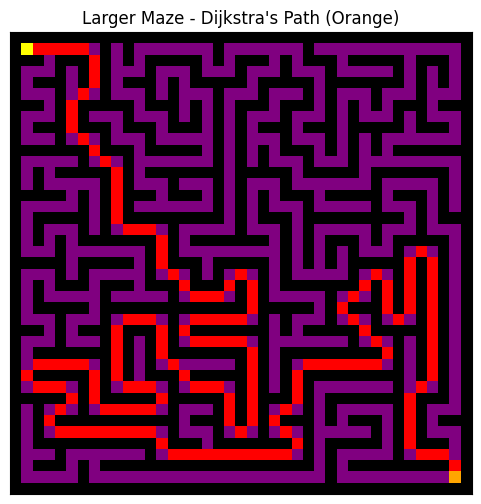

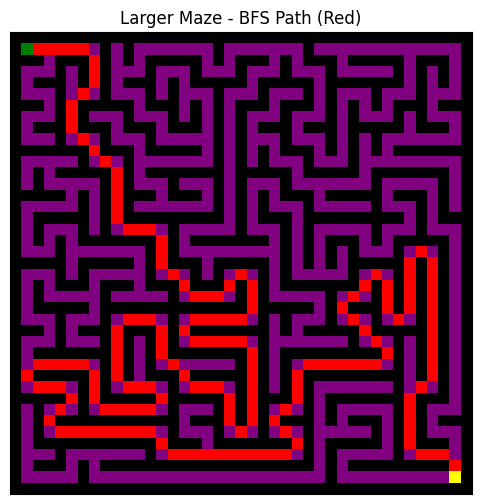

In [ ]:
# Generate a larger maze (e.g., 20x20 conceptual size)
maze_size_conceptual_large = 20
new_maze_large = generate_maze_recursive_backtracker(size=maze_size_conceptual_large)

# Define start and goal for the larger maze
start_large = (1, 1)
goal_large = (new_maze_large.shape[0] - 2, new_maze_large.shape[1] - 2)

# Ensure start and goal are clear
new_maze_large[start_large] = 0
new_maze_large[goal_large] = 0

print(f"Generated a larger maze ({maze_size_conceptual_large}x{maze_size_conceptual_large} conceptual size).")

times_large = {}
path_lengths_large = {'Algorithm': ['A*', 'Dijkstra', 'BFS'], 'Path Length': []}

# Time A*
start_time = time.perf_counter()
path_new_large = astar(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['A*'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_new_large) if path_new_large else 'No Path')

# Time Dijkstra
start_time = time.perf_counter()
path_dijkstra_large = dijkstra(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['Dijkstra'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_dijkstra_large) if path_dijkstra_large else 'No Path')

# Time BFS
start_time = time.perf_counter()
path_bfs_large = bfs(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['BFS'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_bfs_large) if path_bfs_large else 'No Path')

print("\nComputational times for larger maze:", times_large)

df_comparison_large = pd.DataFrame(path_lengths_large)
print("\nPath Length Comparison (Larger Maze):")
display(df_comparison_large)

algorithms_large = list(times_large.keys())
time_values_large = list(times_large.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=algorithms_large, y=time_values_large, hue=algorithms_large, palette='viridis', legend=False)
plt.title('Computational Time Comparison for Larger Maze')
plt.xlabel('Algorithm')
plt.ylabel('Time (seconds)')
plt.show()

# Visualize paths in the larger maze
if path_new_large: visualize(new_maze_large, path_new_large, start_large, goal_large, title="Larger Maze - A* Path (Cyan)", path_color=2)
if path_dijkstra_large: visualize(new_maze_large, path_dijkstra_large, start_large, goal_large, title="Larger Maze - Dijkstra's Path (Orange)", path_color=5)
if path_bfs_large: visualize(new_maze_large, path_bfs_large, start_large, goal_large, title="Larger Maze - BFS Path (Red)", path_color=6)
else: print("No path found for one or more algorithms in the larger maze.")

In [ ]:
import collections

def bfs(maze, start, goal):
    rows, cols = maze.shape
    queue = collections.deque([(start, [start])]) # (current_node, path_to_current)
    visited = {start}

    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    while queue:
        current_node, path = queue.popleft()

        if current_node == goal:
            return path

        for d in directions:
            neighbor = (current_node[0] + d[0], current_node[1] + d[1])

            if (0 <= neighbor[0] < rows and
                0 <= neighbor[1] < cols and
                maze[neighbor] == 0 and
                neighbor not in visited):

                visited.add(neighbor)
                new_path = path + [neighbor]
                queue.append((neighbor, new_path))

    return None

## Consolidated Demonstrations and Comparisons

### 1. Unweighted Maze Pathfinding (A*, Dijkstra, BFS)

Generated a maze using Recursive Backtracker.

Path Length Comparison (Unweighted Maze):


,Algorithm,Path Length
0,A*,66
1,Dijkstra,66
2,BFS,66


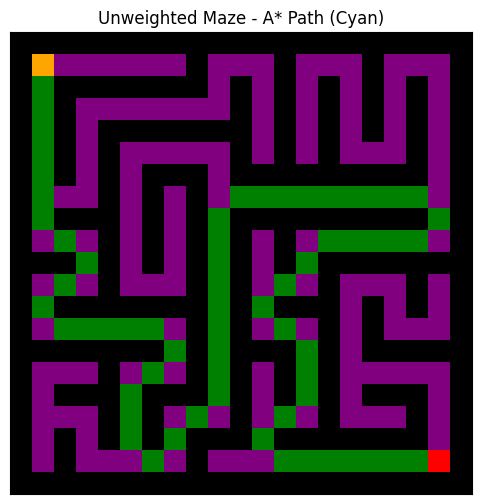

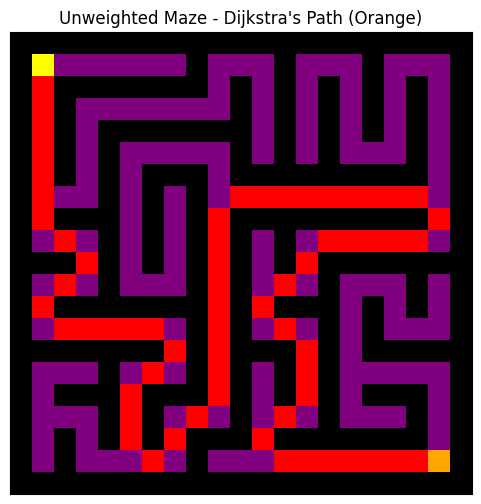

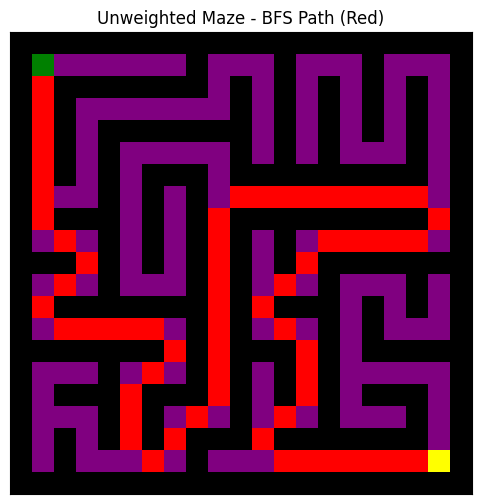

In [ ]:
# Generate a new maze using the recursive backtracker
maze_size_conceptual = 10 # This refers to the grid of cells, not the numpy array size
new_maze = generate_maze_recursive_backtracker(size=maze_size_conceptual)

# Define start and goal for the new maze
# These need to be on the 'path' cells of the numpy array
# (1,1) for the top-left cell, (2*size-1, 2*size-1) for the bottom-right
start_new = (1, 1)
goal_new = (new_maze.shape[0] - 2, new_maze.shape[1] - 2)

# Ensure start and goal are clear in case of very specific maze generation edge cases
new_maze[start_new] = 0
new_maze[goal_new] = 0

print("Generated a maze using Recursive Backtracker.")

# Find paths using all three algorithms
path_astar = astar(new_maze, start_new, goal_new)
path_dijkstra = dijkstra(new_maze, start_new, goal_new)
path_bfs = bfs(new_maze, start_new, goal_new)

# Display path lengths comparison
path_lengths = {
    'Algorithm': ['A*', 'Dijkstra', 'BFS'],
    'Path Length': [
        len(path_astar) if path_astar else 'No Path',
        len(path_dijkstra) if path_dijkstra else 'No Path',
        len(path_bfs) if path_bfs else 'No Path'
    ]
}
df_comparison = pd.DataFrame(path_lengths)
print("\nPath Length Comparison (Unweighted Maze):")
display(df_comparison)

# Visualize paths
if path_astar: visualize(new_maze, path_astar, start_new, goal_new, title="Unweighted Maze - A* Path (Cyan)", path_color=2)
if path_dijkstra: visualize(new_maze, path_dijkstra, start_new, goal_new, title="Unweighted Maze - Dijkstra's Path (Orange)", path_color=5)
if path_bfs: visualize(new_maze, path_bfs, start_new, goal_new, title="Unweighted Maze - BFS Path (Red)", path_color=6)
else: print("No path found for one or more algorithms in the unweighted maze.")

### 2. Weighted Maze Pathfinding (A*, Dijkstra, BFS)

Generated a weighted maze with normal paths (cost 1.0) and mud paths (cost 5.0).

Path Cost and Length Comparison (Weighted Maze):


,Algorithm,Total Cost / Steps,Number of Steps
0,A* (Weighted Cost),236.47,106
1,Dijkstra (Weighted Cost),236.47,106
2,BFS (Steps),100.00,100


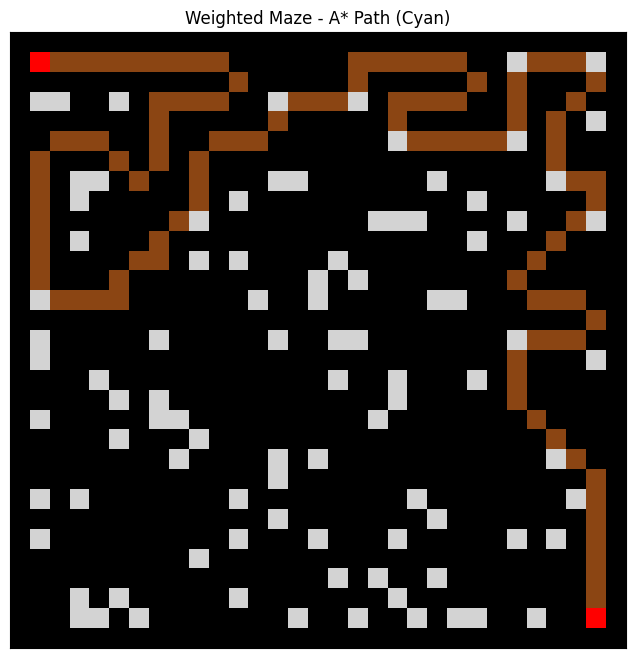

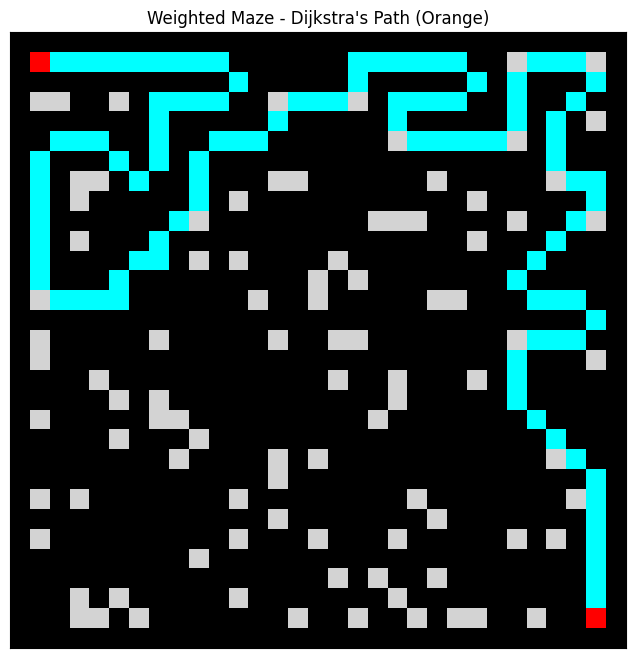

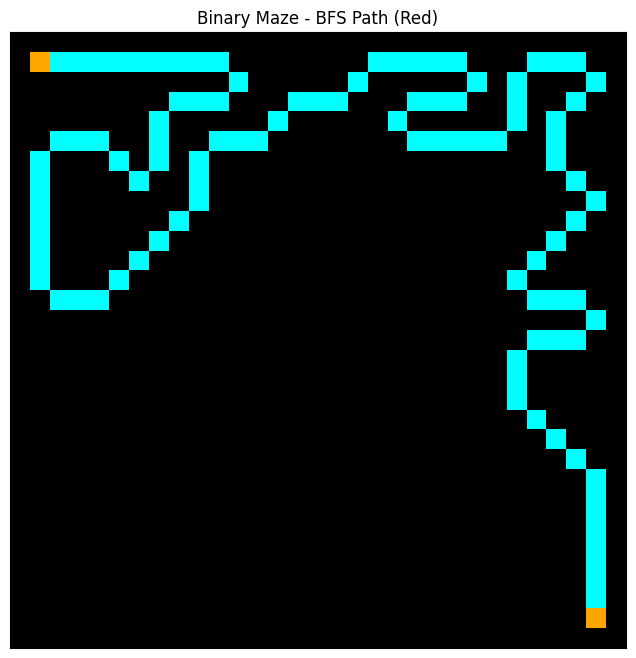

In [ ]:
# Generate a new binary maze using the recursive backtracker
maze_size_conceptual_weighted = 15 # A slightly larger maze for better terrain visualization
binary_maze_weighted = generate_maze_recursive_backtracker(size=maze_size_conceptual_weighted)

# Create a weighted maze from the binary maze
weighted_maze_costs = create_weighted_maze(binary_maze_weighted, normal_cost=1.0, mud_cost=5.0, mud_prob=0.3)

# Define start and goal (in conceptual maze coordinates)
start_weighted = (1, 1)
goal_weighted = (weighted_maze_costs.shape[0] - 2, weighted_maze_costs.shape[1] - 2)

# Ensure start and goal are always normal path cells
weighted_maze_costs[start_weighted] = 1.0
weighted_maze_costs[goal_weighted] = 1.0

print("Generated a weighted maze with normal paths (cost 1.0) and mud paths (cost 5.0).")

# Find paths using the modified algorithms
path_astar_weighted = astar_weighted(weighted_maze_costs, start_weighted, goal_weighted)
path_dijkstra_weighted = dijkstra_weighted(weighted_maze_costs, start_weighted, goal_weighted)
# BFS still runs on the binary maze to compare step-optimal vs cost-optimal
path_bfs_unweighted = bfs(binary_maze_weighted, start_weighted, goal_weighted)

# Calculate actual total costs for A* and Dijkstra
def calculate_path_cost(path, weighted_maze):
    if not path or len(path) < 2:
        return 0
    total_cost = 0
    for i in range(1, len(path)):
        current_node = path[i-1]
        next_node = path[i]
        step_dist = calculate_step_distance(current_node, next_node)
        # For weighted algorithms, cost is terrain cost of the next node * step_distance
        total_cost += weighted_maze[next_node] * step_dist
    return total_cost

# Display path costs and lengths
weighted_path_costs = {
    'Algorithm': ['A* (Weighted Cost)', 'Dijkstra (Weighted Cost)', 'BFS (Steps)'],
    'Total Cost / Steps': [
        round(calculate_path_cost(path_astar_weighted, weighted_maze_costs), 2) if path_astar_weighted else 'No Path',
        round(calculate_path_cost(path_dijkstra_weighted, weighted_maze_costs), 2) if path_dijkstra_weighted else 'No Path',
        len(path_bfs_unweighted) if path_bfs_unweighted else 'No Path' # BFS cost is just steps here
    ],
    'Number of Steps': [
        len(path_astar_weighted) if path_astar_weighted else 'No Path',
        len(path_dijkstra_weighted) if path_dijkstra_weighted else 'No Path',
        len(path_bfs_unweighted) if path_bfs_unweighted else 'No Path'
    ]
}
df_weighted_comparison = pd.DataFrame(weighted_path_costs)
print("\nPath Cost and Length Comparison (Weighted Maze):")
display(df_weighted_comparison)

# Visualize paths on the weighted maze
if path_astar_weighted: visualize_weighted(weighted_maze_costs, path_astar_weighted, start_weighted, goal_weighted, title="Weighted Maze - A* Path (Cyan)", path_color_code=3)
if path_dijkstra_weighted: visualize_weighted(weighted_maze_costs, path_dijkstra_weighted, start_weighted, goal_weighted, title="Weighted Maze - Dijkstra's Path (Orange)", path_color_code=4)
# BFS visualization on the binary maze, not the weighted cost map
if path_bfs_unweighted: visualize_weighted(binary_maze_weighted, path_bfs_unweighted, start_weighted, goal_weighted, title="Binary Maze - BFS Path (Red)", path_color_code=5)
else: print("No path found for one or more algorithms in the weighted maze.")

### 3. Algorithm Performance Benchmarking on Larger Maze

Generated a larger maze (20x20 conceptual size).

Computational times for larger maze: {'A*': 0.002665698999862798, 'Dijkstra': 0.002681519999896409, 'BFS': 0.0019188900000699505}

Path Length Comparison (Larger Maze):


,Algorithm,Path Length
0,A*,198
1,Dijkstra,198
2,BFS,198


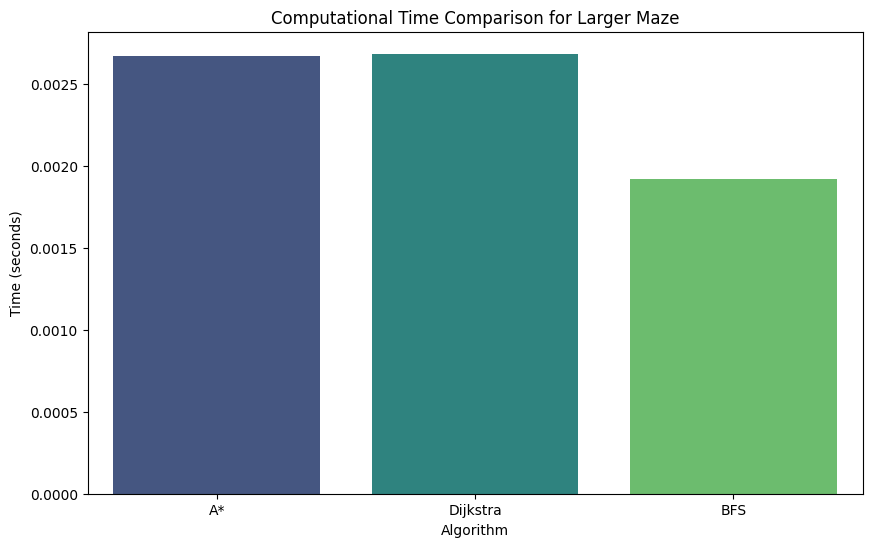

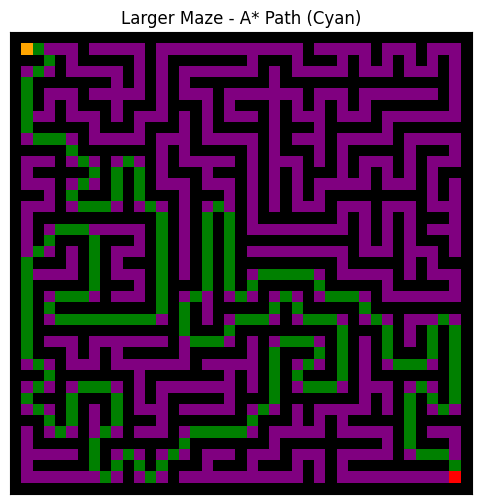

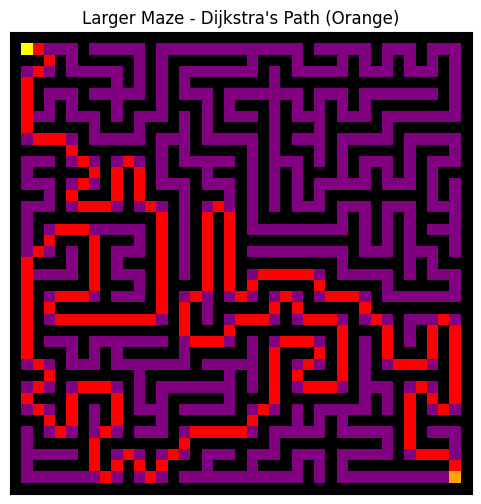

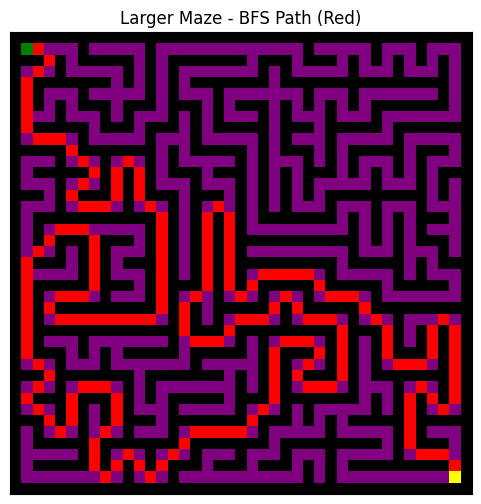

In [ ]:
# Generate a larger maze (e.g., 20x20 conceptual size)
maze_size_conceptual_large = 20
new_maze_large = generate_maze_recursive_backtracker(size=maze_size_conceptual_large)

# Define start and goal for the larger maze
start_large = (1, 1)
goal_large = (new_maze_large.shape[0] - 2, new_maze_large.shape[1] - 2)

# Ensure start and goal are clear
new_maze_large[start_large] = 0
new_maze_large[goal_large] = 0

print(f"Generated a larger maze ({maze_size_conceptual_large}x{maze_size_conceptual_large} conceptual size).")

times_large = {}
path_lengths_large = {'Algorithm': ['A*', 'Dijkstra', 'BFS'], 'Path Length': []}

# Time A*
start_time = time.perf_counter()
path_new_large = astar(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['A*'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_new_large) if path_new_large else 'No Path')

# Time Dijkstra
start_time = time.perf_counter()
path_dijkstra_large = dijkstra(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['Dijkstra'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_dijkstra_large) if path_dijkstra_large else 'No Path')

# Time BFS
start_time = time.perf_counter()
path_bfs_large = bfs(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['BFS'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_bfs_large) if path_bfs_large else 'No Path')

print("\nComputational times for larger maze:", times_large)

df_comparison_large = pd.DataFrame(path_lengths_large)
print("\nPath Length Comparison (Larger Maze):")
display(df_comparison_large)

algorithms_large = list(times_large.keys())
time_values_large = list(times_large.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=algorithms_large, y=time_values_large, hue=algorithms_large, palette='viridis', legend=False)
plt.title('Computational Time Comparison for Larger Maze')
plt.xlabel('Algorithm')
plt.ylabel('Time (seconds)')
plt.show()

# Visualize paths in the larger maze
if path_new_large: visualize(new_maze_large, path_new_large, start_large, goal_large, title="Larger Maze - A* Path (Cyan)", path_color=2)
if path_dijkstra_large: visualize(new_maze_large, path_dijkstra_large, start_large, goal_large, title="Larger Maze - Dijkstra's Path (Orange)", path_color=5)
if path_bfs_large: visualize(new_maze_large, path_bfs_large, start_large, goal_large, title="Larger Maze - BFS Path (Red)", path_color=6)
else: print("No path found for one or more algorithms in the larger maze.")

In [ ]:
# Find path using Dijkstra's algorithm (re-executing for robustness)
path_dijkstra = dijkstra(new_maze, start_new, goal_new)

import pandas as pd

path_lengths = {
    'Algorithm': ['A*', 'Dijkstra', 'BFS'],
    'Path Length': [
        len(path_new) if path_new else 'No Path',
        len(path_dijkstra) if path_dijkstra else 'No Path',
        len(path_bfs) if path_bfs else 'No Path'
    ]
}

df_comparison = pd.DataFrame(path_lengths)
display(df_comparison)

,Algorithm,Path Length
0,A*,38
1,Dijkstra,66
2,BFS,66


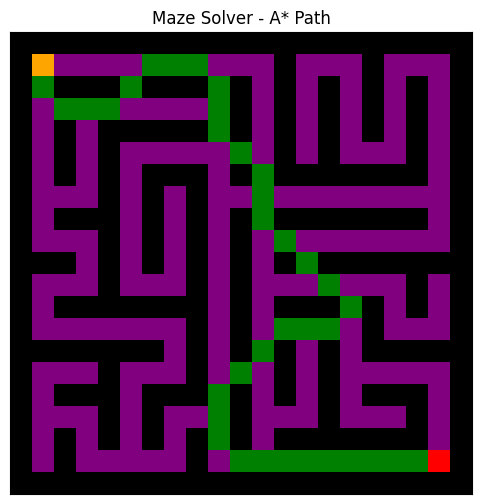

In [ ]:
visualize(new_maze, path_new, start_new, goal_new, title="Maze Solver - A* Path", path_color=2)

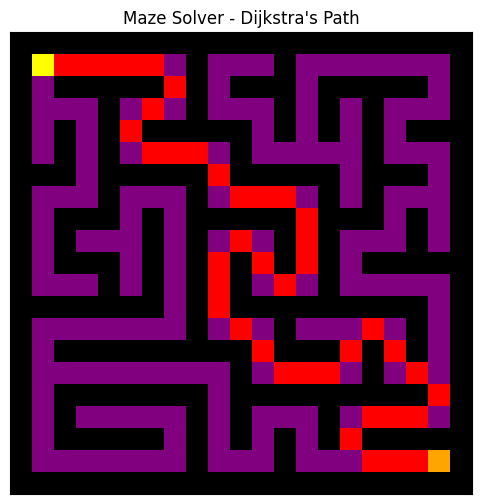

In [ ]:
visualize(new_maze, path_dijkstra, start_new, goal_new, title="Maze Solver - Dijkstra's Path", path_color=5)

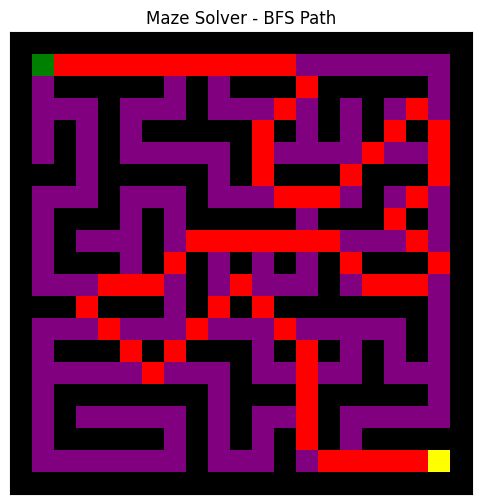

In [ ]:
visualize(new_maze, path_bfs, start_new, goal_new, title="Maze Solver - BFS Path", path_color=6)

### Testing Algorithm Performance on a Larger Maze

In [ ]:
# Generate a larger maze (e.g., 20x20 conceptual size)
maze_size_conceptual_large = 20
new_maze_large = generate_maze_recursive_backtracker(size=maze_size_conceptual_large)

# Define start and goal for the larger maze
start_large = (1, 1)
goal_large = (new_maze_large.shape[0] - 2, new_maze_large.shape[1] - 2)

# Ensure start and goal are clear
new_maze_large[start_large] = 0
new_maze_large[goal_large] = 0

print(f"Generated a larger maze ({maze_size_conceptual_large}x{maze_size_conceptual_large} conceptual size).")


Generated a larger maze (20x20 conceptual size).


In [ ]:
times_large = {}
path_lengths_large = {'Algorithm': ['A*', 'Dijkstra', 'BFS'], 'Path Length': []}

# Time A*
start_time = time.perf_counter()
path_new_large = astar(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['A*'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_new_large) if path_new_large else 'No Path')

# Time Dijkstra
start_time = time.perf_counter()
path_dijkstra_large = dijkstra(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['Dijkstra'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_dijkstra_large) if path_dijkstra_large else 'No Path')

# Time BFS
start_time = time.perf_counter()
path_bfs_large = bfs(new_maze_large, start_large, goal_large)
end_time = time.perf_counter()
times_large['BFS'] = end_time - start_time
path_lengths_large['Path Length'].append(len(path_bfs_large) if path_bfs_large else 'No Path')

print("Computational times for larger maze:", times_large)

df_comparison_large = pd.DataFrame(path_lengths_large)
display(df_comparison_large)


Computational times for larger maze: {'A*': 0.001507290000517969, 'Dijkstra': 0.0018522599993957556, 'BFS': 0.0010305800005880883}


,Algorithm,Path Length
0,A*,174
1,Dijkstra,174
2,BFS,174


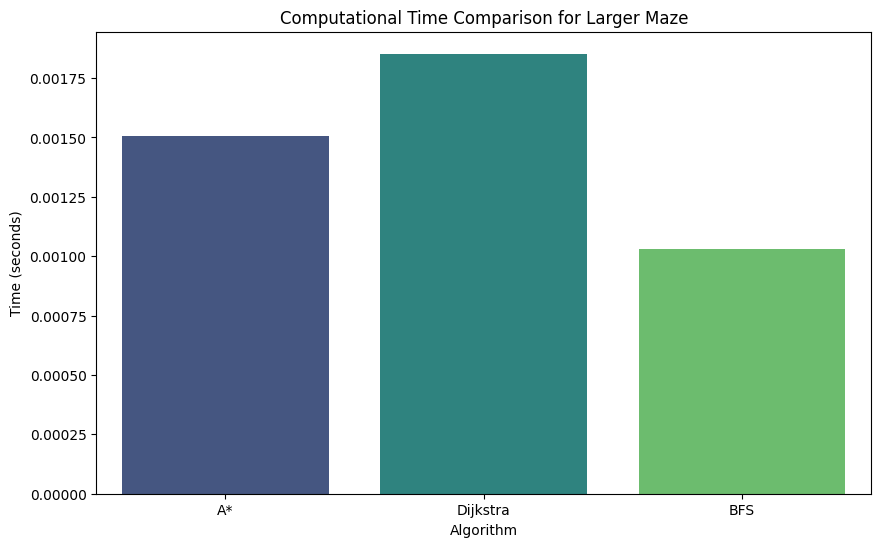

In [ ]:
algorithms_large = list(times_large.keys())
time_values_large = list(times_large.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=algorithms_large, y=time_values_large, hue=algorithms_large, palette='viridis', legend=False)
plt.title('Computational Time Comparison for Larger Maze')
plt.xlabel('Algorithm')
plt.ylabel('Time (seconds)')
plt.show()


### Visualizing Paths in Larger Maze (Optional)

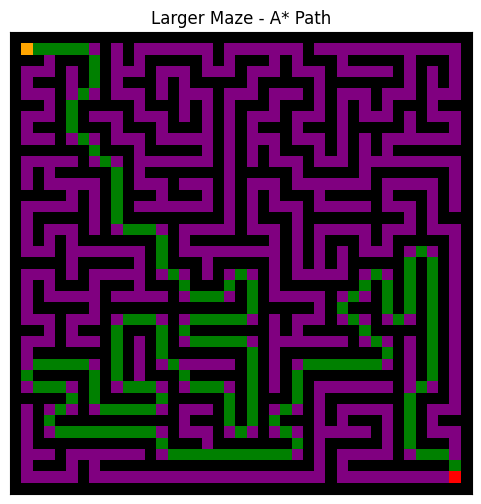

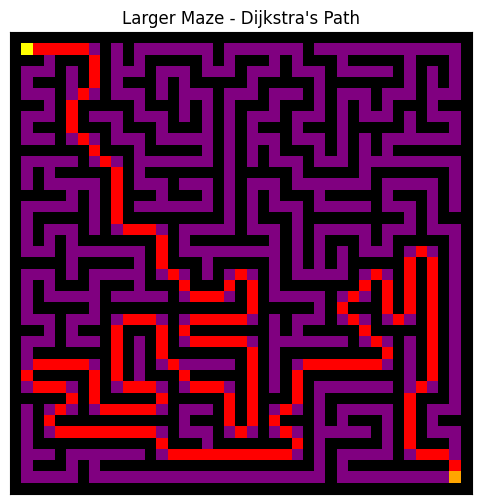

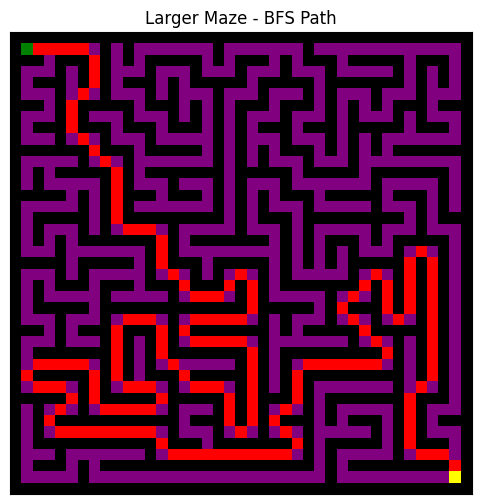

In [ ]:
visualize(new_maze_large, path_new_large, start_large, goal_large, title="Larger Maze - A* Path", path_color=2)
visualize(new_maze_large, path_dijkstra_large, start_large, goal_large, title="Larger Maze - Dijkstra's Path", path_color=5)
visualize(new_maze_large, path_bfs_large, start_large, goal_large, title="Larger Maze - BFS Path", path_color=6)


In [ ]:
import time

times = {}

# Time A*
start_time = time.perf_counter()
path_new = astar(new_maze, start_new, goal_new)
end_time = time.perf_counter()
times['A*'] = end_time - start_time

# Time Dijkstra
start_time = time.perf_counter()
path_dijkstra = dijkstra(new_maze, start_new, goal_new)
end_time = time.perf_counter()
times['Dijkstra'] = end_time - start_time

# Time BFS
start_time = time.perf_counter()
path_bfs = bfs(new_maze, start_new, goal_new)
end_time = time.perf_counter()
times['BFS'] = end_time - start_time

print("Computational times:", times)

Computational times: {'A*': 0.0006482300004790886, 'Dijkstra': 0.0007703400005993899, 'BFS': 0.0005540900001506088}


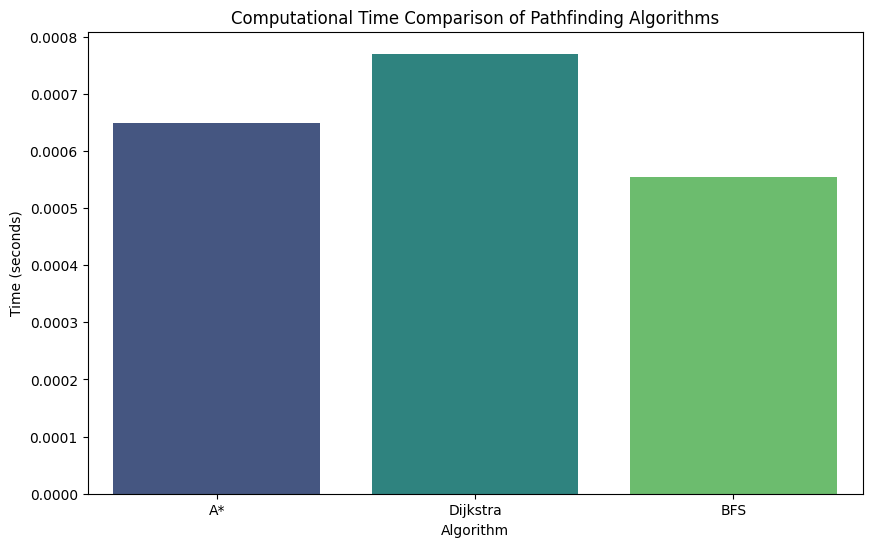

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

algorithms = list(times.keys())
time_values = list(times.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=algorithms, y=time_values, hue=algorithms, palette='viridis', legend=False)
plt.title('Computational Time Comparison of Pathfinding Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Time (seconds)')
plt.show()